In [41]:
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import scipy.stats
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, ParameterGrid
from scipy.signal import butter, sosfilt

from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Amplitude, NumberOfPoints

import math


In [3]:
SAMPLE_RATE = 16_000

DCASE2024_ROOT_PATH = Path.cwd().parent / "data/raw/dcase-2024"

DCASE2024_TRAIN_PATH = DCASE2024_ROOT_PATH / "Train"
DCASE2024_DEV_PATH = DCASE2024_ROOT_PATH / "Dev"
DCASE2024_EVAL_PATH = DCASE2024_ROOT_PATH / "Eval"

DCASE2022_ROOT_PATH = Path.cwd().parent / "data/raw/dcase-2022"

DCASE2022_TRAIN_PATH = DCASE2022_ROOT_PATH / "Train"
DCASE2022_DEV_PATH = DCASE2022_ROOT_PATH / "Dev"

MACHINE_TYPES = ['fan']
SECTIONS = ['section_00']


In [4]:
def load_audio(audio):
    signal, sample_rate = librosa.load(audio, mono=True, sr=SAMPLE_RATE)

    return signal, sample_rate

def pad_or_trim(signal, target_len):
    if len(signal) > target_len:
        return signal[:target_len]
    elif len(signal) < target_len:
        return np.pad(signal, (0, target_len - len(signal)), 'constant')
   
    return signal

def preprocess_data(signals, 
                    padding_or_trim=True, 
                    denoise_method=None, 
                    normalize_method=None):

    new_signals = []
    target_len = 10 * SAMPLE_RATE

    for signal in signals:
        if padding_or_trim:
            signal = pad_or_trim(signal, target_len)
        if denoise_method:
            signal = denoise_method(signal)
        if normalize_method:
            signal = normalize_method(signal)
        
        new_signals.append(signal)

    return np.array(new_signals)

def create_windows(signal, size, stride):
    frame_length = int(size*SAMPLE_RATE)
    hop_length = int(stride*SAMPLE_RATE)

    windows = librosa.util.frame(signal, frame_length=frame_length, hop_length=hop_length)

    return windows.T

In [5]:
def read_dcase_dev_set(
    path,  
    only_machine_type=[], 
    only_section=[]):

    signals_train, y_train = [], []
    signals_test, y_test = [], []

    for machine_dir in path.iterdir():
        machine_type = machine_dir.name

        if only_machine_type and machine_type not in only_machine_type: continue

        for audio_set in ['train', 'test']:
            audios_dir = machine_dir / audio_set
            wavs = list(audios_dir.glob("*.wav"))

            for audio_file in tqdm(wavs, desc=f"{machine_type} - {audio_set}"):
                split_name = audio_file.name.split('_')
                section = f'{split_name[0]}_{split_name[1]}'

                if only_section and section not in only_section: continue
                
                try:
                    signal, _ = load_audio(audio_file)

                    if audio_set == "train":
                        label = 0
                        signals_train.append(signal)
                        y_train.append(label)

                    else:
                        label = 1 if "anomaly" in audio_file.name.lower() else 0
                        signals_test.append(signal)
                        y_test.append(label)

                except Exception as e:
                    print(f"Erro ao processar {audio_file.name}: {e}")
    
    return np.array(signals_train), \
           np.array(signals_test), \
           np.array(y_train), \
           np.array(y_test)

In [6]:
(signals_train, 
signals_test, 
labels_train, 
labels_test, 
) = read_dcase_dev_set(DCASE2022_DEV_PATH, only_machine_type=MACHINE_TYPES, only_section=SECTIONS)

fan - test: 100%|██████████| 600/600 [00:01<00:00, 359.83it/s]


In [7]:
signals_train = preprocess_data(signals_train)
signals_test = preprocess_data(signals_test)

In [8]:
def get_mfcc_features(signal):
    mfcc_features = librosa.feature.mfcc(y=signal, sr=SAMPLE_RATE, n_mfcc=40, n_fft=512, hop_length=256)

    flatten_mfcc_features = np.mean(mfcc_features, axis=1)

    return flatten_mfcc_features

def get_tda_features(signal):
    signal = signal.reshape(1, -1)

    embedder = TakensEmbedding(time_delay=2, dimension=3)
    X_embedded = embedder.fit_transform(signal)

    vr = VietorisRipsPersistence(homology_dimensions=[0,1])
    diagrams = vr.fit_transform(X_embedded)

    norm_extractor = Amplitude(metric='landscape')
    norm = norm_extractor.fit_transform(diagrams)[0]
    
    dim_extractor = NumberOfPoints()
    dim = dim_extractor.fit_transform(diagrams)[0]

    tda_features = np.concatenate([norm, dim])

    return tda_features

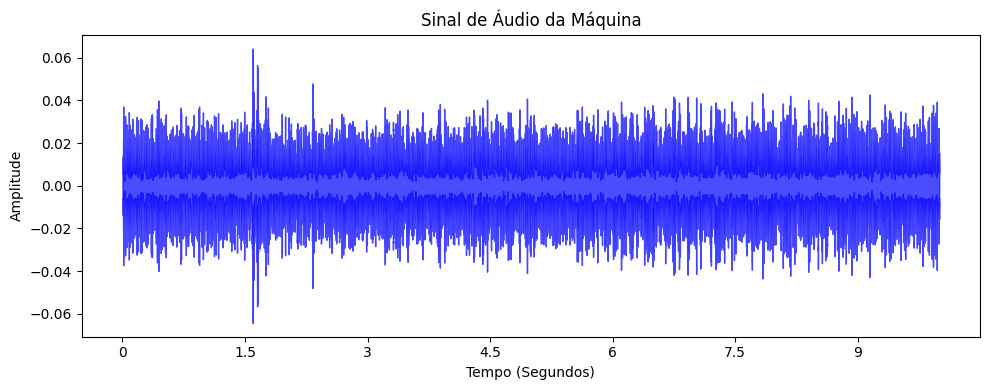

shape dos MFCC de todas as janelas de um único aúdio: (200, 40)
shape dos TDA de todas as janelas de um único aúdio: (200, 4)


In [9]:
plt.figure(figsize=(10, 4))
    
librosa.display.waveshow(y=signals_train[0], sr=SAMPLE_RATE, color="blue", alpha=0.7)

plt.title("Sinal de Áudio da Máquina")
plt.xlabel("Tempo (Segundos)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


windows = create_windows(signals_train[0], 0.050, 0.050)
features_per_windows = []

for window in windows:
    mfcc_features = get_mfcc_features(window)
    tda_features = get_tda_features(window)

    features_per_windows.append((mfcc_features, tda_features))
    

mfcc_per_windows = np.array([features[0] for features in features_per_windows])
tda_per_windows = np.array([features[1] for features in features_per_windows])

print(f'shape dos MFCC de todas as janelas de um único aúdio: {mfcc_per_windows.shape}')
print(f'shape dos TDA de todas as janelas de um único aúdio: {tda_per_windows.shape}')

In [30]:
class TDAAttentionModel(nn.Module):
    def __init__(self, input_dim=4, embed_dim=16, num_heads=2):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, embed_dim)

        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, embed_dim)
        )
    
    def forward(self, tda_seq):
        x = self.input_projection(tda_seq)

        attn_out, _ = self.attention(x, x, x)

        output = self.mlp(attn_out)

        return output

class NBeatsBlock(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        
        self.mlp = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, input_size)
        )
    
    def forward(self, x):
        return x + self.mlp(x)
        
class PositionalEmbedding(nn.Module):
    def __init__(self, max_length, embed_dim, dropout=0.1):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(max_length, embed_dim) * 0.02)
        self.dropout = nn.Dropout(dropout)
        
        def forward(self, X):
            return self.dropout(X + self.pos_embed[:X.size(1)])

In [ ]:
class TDANetC(nn.Module):
    def __init__(self, tda_dim=4, mfcc_dim=40, embed_dim=16, hidden_size=64, num_heads=2):
        super().__init__()

        input_size = embed_dim + mfcc_dim

        self.tda_attention = TDAAttentionModel(input_dim=tda_dim, embed_dim=embed_dim, num_heads=num_heads)
        self.conv1d = nn.Conv1d(in_channels=embed_dim+mfcc_dim, out_channels=hidden_size, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.lstm = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size, num_layers=1, batch_first=True)

        self.mlp = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, input_size),
        )
    
    def forward(self, tda_seq, mfcc_seq):
        tda_features = self.tda_attention(tda_seq)
        cat_features = torch.cat([tda_features, mfcc_seq], dim=2)

        cat_features = cat_features.permute(0, 2, 1)
        cat_features = self.relu(self.conv1d(cat_features))
        cat_features = cat_features.permute(0, 2, 1)

        lstm_out, _ = self.lstm(cat_features)

        return self.mlp(lstm_out[:, -1, :])


class TDANetN(nn.Module):
    def __init__(self, tda_dim=4, mfcc_dim=40, embed_dim=16, num_heads=2):
        super().__init__()

        self.tda_attention = TDAAttentionModel(input_dim=tda_dim, embed_dim=embed_dim, num_heads=num_heads)

        input_size = embed_dim + mfcc_dim

        self.nbeats_stack = nn.Sequential(
            NBeatsBlock(input_size),
            nn.ReLU(),
            NBeatsBlock(input_size),
            nn.ReLU()
        )

        self.mlp = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, tda_seq, mfcc_seq):
        tda_features = self.tda_attention(tda_seq)
        cat_features = torch.cat([tda_features, mfcc_seq], dim=2)

        nbeats_out = self.nbeats_stack(cat_features)

        global_mean = torch.mean(nbeats_out, dim=1)

        return self.mlp(global_mean)

class TDANetT(nn.Module):
    def __init__(self, tda_dim=4, mfcc_dim=40, embed_dim=16, num_heads=4):
        super().__init__()

        self.tda_attention = TDAAttentionModel(input_dim=tda_dim, embed_dim=embed_dim, num_heads=num_heads)

        input_size = embed_dim + mfcc_dim

        self.pos_embedding = PositionalEmbedding(max_length=300, embed_dim=input_size)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_size,
            nhead=num_heads,
            dim_feedforward=128,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.mlp = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self, tda_seq, mfcc_seq):
        tda_features = self.tda_attention(tda_seq)

        cat_features = torch.cat([tda_features, mfcc_seq], dim=2)
        cat_features = self.pos_embedding(cat_features)

        transformer_out = self.transformer(cat_features)

        global_mean = torch.mean(transformer_out, dim=1)

        return self.mlp(global_mean)

In [ ]:
def extract_features_from_signals(signals):
    features = []

    for signal in signals[:10]:
        windows = create_windows(signal, 0.050, 0.050)
        features_per_windows = []

        for window in windows:
            mfcc_features = get_mfcc_features(window)
            tda_features = get_tda_features(window)

            features_per_windows.append((mfcc_features, tda_features))
        
        mfcc_per_windows = np.array([features[0] for features in features_per_windows])
        tda_per_windows = np.array([features[1] for features in features_per_windows])

        mfcc_per_windows = torch.tensor(mfcc_per_windows, dtype=torch.float32)
        tda_per_windows = torch.tensor(tda_per_windows, dtype=torch.float32)

        features.append([mfcc_per_windows, tda_per_windows])

    return features

X_train = extract_features_from_signals(signals_train)
X_test = extract_features_from_signals(signals_test)

In [44]:
print(f"Total de áudios no treino: {len(X_train)}")

mfcc_shape = X_train[0][0].shape
tda_shape = X_train[0][1].shape

print(f"Shape do MFCC (janelas, features): {mfcc_shape}")
print(f"Shape do TDA (janelas, features): {tda_shape}")

print()

print(f"Total de áudios no teste: {len(X_test)}")

mfcc_shape = X_test[0][0].shape
tda_shape = X_test[0][1].shape

print(f"Shape do MFCC (janelas, features): {mfcc_shape}")
print(f"Shape do TDA (janelas, features): {tda_shape}")

Total de áudios no treino: 10
Shape do MFCC (janelas, features): torch.Size([200, 40])
Shape do TDA (janelas, features): torch.Size([200, 4])

Total de áudios no teste: 10
Shape do MFCC (janelas, features): torch.Size([200, 40])
Shape do TDA (janelas, features): torch.Size([200, 4])


In [48]:
class MachineAudioDataset(Dataset):
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        mfcc = self.data[idx][0]
        tda = self.data[idx][1]

        return tda, mfcc

train_dataset = MachineAudioDataset(X_train)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

test_dataset = MachineAudioDataset(X_test)
test_loader = DataLoader(test_dataset, batch_size=2)

In [46]:
model = TDANetC(tda_dim=tda_per_windows.shape[1], mfcc_dim=mfcc_per_windows.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

model.train()

for epoch in range(num_epochs):
    total_loss = 0

    for tda_batch, mfcc_batch in train_loader:
        optimizer.zero_grad()

        tda_input = tda_batch[:, :-1, :]
        mfcc_input = mfcc_batch[:, :-1, :]

        tda_output = tda_batch[:, -1, :]
        mfcc_output = mfcc_batch[:, -1, :]

        true_output = torch.cat([tda_output, mfcc_output], dim=1)

        pred_output = model(tda_input, mfcc_input)

        error = criterion(pred_output, true_output)
        error.backward()
        optimizer.step()

        total_loss += error.item()
    
    mean_error = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | MSE Error: {mean_error:.4f}")


c:\Users\josel\OneDrive\Desktop\NCIA\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([2, 44])) that is different to the input size (torch.Size([2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/5 | MSE Error: 21712.2910
Epoch 2/5 | MSE Error: 21708.8129
Epoch 3/5 | MSE Error: 21705.8594
Epoch 4/5 | MSE Error: 21702.8742
Epoch 5/5 | MSE Error: 21700.5871


In [ ]:
model.eval()

scores = []

with torch.no_grad():
    for tda_batch, mfcc_batch in test_loader:
        tda_input = tda_batch[:, :-1, :]
        mfcc_input = mfcc_batch[:, :-1, :]
        
        tda_output = tda_batch[:, -1, :]
        mfcc_output = mfcc_batch[:, -1, :]
        
        true_output = torch.cat([tda_output, mfcc_output], dim=1)
        pred_output = model(tda_input, mfcc_input)

        errors = (pred_output - true_output) ** 2
        error_per_audio = torch.mean(errors, dim=1)
        
        scores.extend(error_per_audio.tolist())

scores = np.array(scores)

auc_score = roc_auc_score(labels_test[:10], scores)
print(f"\n=== RESULTADOS FINAIS ===")
print(f"AUC-ROC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(labels_test[:10], scores)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

y_pred = (scores > best_threshold).astype(int)
print(f"\nLinha de Corte Ideal: {best_threshold:.4f}")
print(classification_report(labels_test[:10], y_pred, target_names=["Normal (0)", "Anomalia (1)"]))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Acaso (AUC = 0.500)')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', marker='o', s=100, label='best Corte')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Detecção de Anomalias (TDANetC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()